In [17]:
import h5py

path = "/Users/carlasequero/Desktop/trabajo-fin-master/solution/dataset_extraction_pipeline/data/06_training_data/training_03.h5"

with h5py.File(path, "r") as f:
    print(list(f.keys()))

import numpy as np

with h5py.File(path, "r") as f:
    X = f["X"][:]
    gaia_ID = f["gaia_source_id"][:]

print(gaia_ID.shape)

['X', 'X_err', 'gaia_source_id', 'gaia_wavelength_nm', 'sdss_obj_id', 'sdss_wavelength_aa', 'y']
(55621,)


In [18]:
from astropy.table import Table
import numpy as np
from pathlib import Path

# Cargamos la tabla de Gaia guardada en local
gaia_data_path = Path("../data/gaia_data.ecsv")

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

In [19]:
# Usamos solo los id comunes
gaia_data_df_no_dup = gaia_data_df[
    gaia_data_df["source_id"].isin(gaia_ID)
].copy()


In [20]:
print("Filas finales para HR:", len(gaia_data_df_no_dup))

Filas finales para HR: 55368


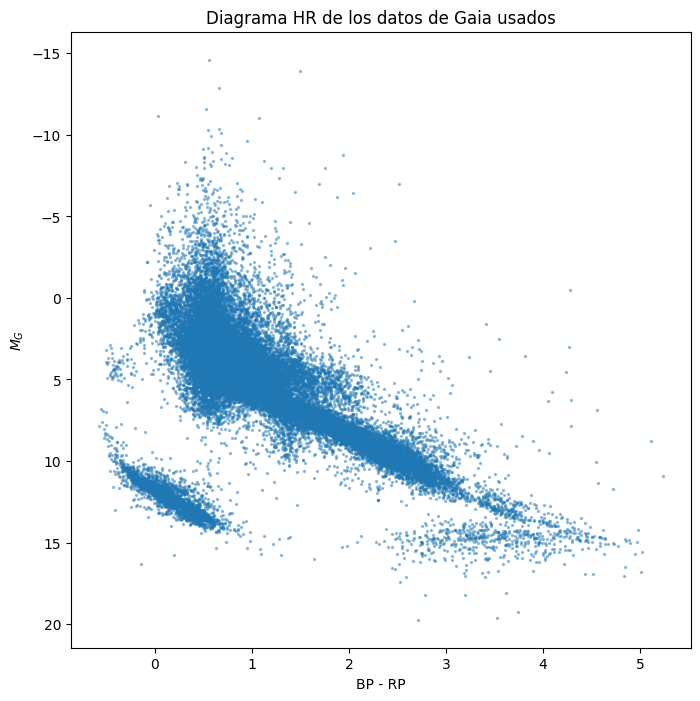

In [22]:
import matplotlib.pyplot as plt
bp_rp = gaia_data_df_no_dup["bp_rp"]
g_mag = gaia_data_df_no_dup["phot_g_mean_mag"]
parallax = gaia_data_df_no_dup["parallax"]

abs_g_mag = g_mag + 5 * np.log10(parallax) - 10

valid_hr = (
    np.isfinite(bp_rp)
    & np.isfinite(abs_g_mag)
    & np.isfinite(parallax)
    & (parallax > 0)
)

plt.figure(figsize=(8, 8))

plt.scatter(
    bp_rp[valid_hr],
    abs_g_mag[valid_hr],
    s=2,
    alpha=0.4
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("$M_G$")
plt.title("Diagrama HR de los datos de Gaia usados")
plt.show()

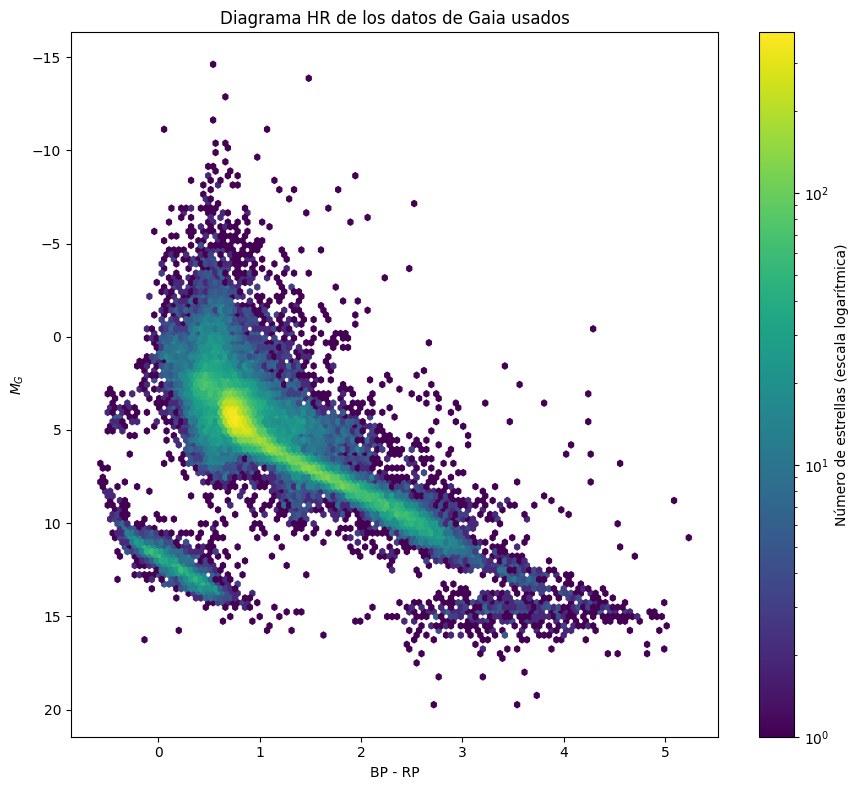

In [23]:
plt.figure(figsize=(9, 8))

plt.hexbin(
    bp_rp[valid_hr],
    abs_g_mag[valid_hr],
    gridsize=120,
    mincnt=1,
    bins="log",
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("$M_G$")
plt.title("Diagrama HR de los datos de Gaia usados")
plt.colorbar(label="Número de estrellas (escala logarítmica)")
plt.tight_layout()
plt.show()